In [ ]:
# Step 1: Download and load the CMAPSS turbofan engine data

import pandas as pd

# Download the training data (FD001 = simplest subset: 100 engines, 1 fault mode)
!wget -q https://raw.githubusercontent.com/mapr-demos/predictive-maintenance/master/notebooks/jupyter/Dataset/CMAPSSData/train_FD001.txt -O train_FD001.txt

# The raw file has NO column headers, so we define them ourselves:
# - unit_number: which engine (1 to 100)
# - time_in_cycles: how many operating cycles this engine has run so far
# - 3 operational settings (things like altitude, speed — conditions the engine ran under)
# - 21 sensor readings (temperatures, pressures, speeds, etc.)
column_names = (
    ['unit_number', 'time_in_cycles'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

# Load it — sep='\s+' means "split on any amount of whitespace" (the file uses spaces, not commas)
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=column_names)

# Now just look at it
print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1525/1267082950.py:20: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=column_names)


Shape (rows, columns): (20631, 26)

First 5 rows:
   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1       -0.0007       -0.0004         100.0   
1            1               2        0.0019       -0.0003         100.0   
2            1               3       -0.0043        0.0003         100.0   
3            1               4        0.0007        0.0000         100.0   
4            1               5       -0.0019       -0.0002         100.0   

   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  \
0    518.67    641.82   1589.70   1400.60     14.62  ...     521.66   
1    518.67    642.15   1591.82   1403.14     14.62  ...     522.28   
2    518.67    642.35   1587.99   1404.20     14.62  ...     522.42   
3    518.67    642.35   1582.79   1401.87     14.62  ...     522.86   
4    518.67    642.37   1582.85   1406.22     14.62  ...     522.19   

   sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  sensor_1

Engine 1 ran for 192 cycles before failing


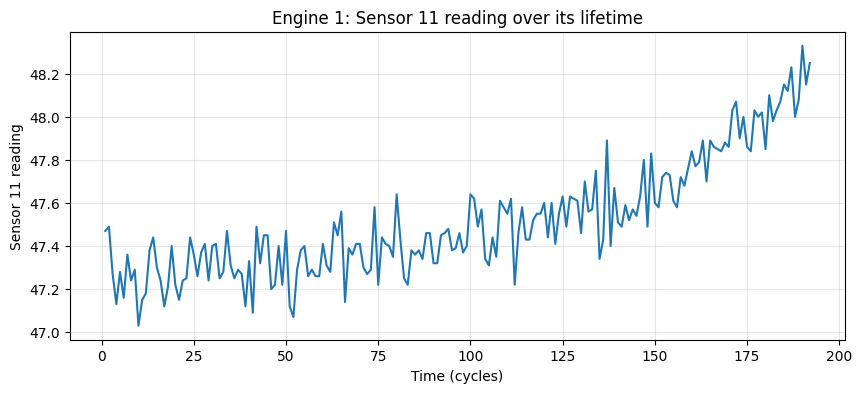

In [ ]:
# Step 2: Look at how one engine's sensors change over its lifetime

import matplotlib.pyplot as plt

# Pull out just engine #1's full history
engine_1 = df[df['unit_number'] == 1]

print(f"Engine 1 ran for {engine_1['time_in_cycles'].max()} cycles before failing")

# Plot a sensor that's known to show clear degradation trends in this dataset
plt.figure(figsize=(10, 4))
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_11'])
plt.xlabel('Time (cycles)')
plt.ylabel('Sensor 11 reading')
plt.title('Engine 1: Sensor 11 reading over its lifetime')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Step 3: Create the target we're trying to predict — Remaining Useful Life (RUL)

# For each engine, find the cycle number where it finally failed (its max cycle)
max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']

# Merge that back into the main dataframe
df = df.merge(max_cycles, on='unit_number')

# RUL at any row = (that engine's final cycle) - (current cycle)
df['RUL'] = df['max_cycles'] - df['time_in_cycles']

# Drop the helper column, we don't need it anymore
df.drop('max_cycles', axis=1, inplace=True)

# Check it on engine 1: RUL should count DOWN to 0 at its last row
print(df[df['unit_number'] == 1][['unit_number', 'time_in_cycles', 'RUL']].tail())

     unit_number  time_in_cycles  RUL
187            1             188    4
188            1             189    3
189            1             190    2
190            1             191    1
191            1             192    0


In [ ]:
# Step 4: Check which sensors actually vary (and which are flat/useless)

sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

# Standard deviation tells us how much each sensor moves.
# A sensor with ~0 std barely changes at all — no useful signal for predicting RUL.
sensor_variation = df[sensor_cols].std().sort_values()

print(sensor_variation)

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [ ]:
# Step 5: Drop flat/near-flat sensors, then set up features (X) and target (y)

flat_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

df_clean = df.drop(columns=flat_sensors)

print("Remaining columns:", df_clean.columns.tolist())
print("New shape:", df_clean.shape)

# Features = everything except identifiers and the target itself
feature_cols = [col for col in df_clean.columns
                 if col not in ['unit_number', 'time_in_cycles', 'RUL']]

X = df_clean[feature_cols]
y = df_clean['RUL']

print("\nFeatures we'll train on:", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape)

Remaining columns: ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']
New shape: (20631, 20)

Features we'll train on: ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
X shape: (20631, 17) | y shape: (20631,)


In [ ]:
# Step 6: Split into train/test, then train a first baseline model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 80% of rows for training, 20% held back to test on
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

# Start simple: Linear Regression as our baseline.
# It just tries to fit a straight-line relationship between sensors and RUL.
model = LinearRegression()
model.fit(X_train, y_train)

# Have it predict RUL on the test set (data it's never seen)
predictions = model.predict(X_test)

# Mean Absolute Error = on average, how many cycles off were our predictions?
mae = mean_absolute_error(y_test, predictions)
print(f"\nMean Absolute Error: {mae:.2f} cycles")

Training rows: 16504
Test rows: 4127

Mean Absolute Error: 34.07 cycles


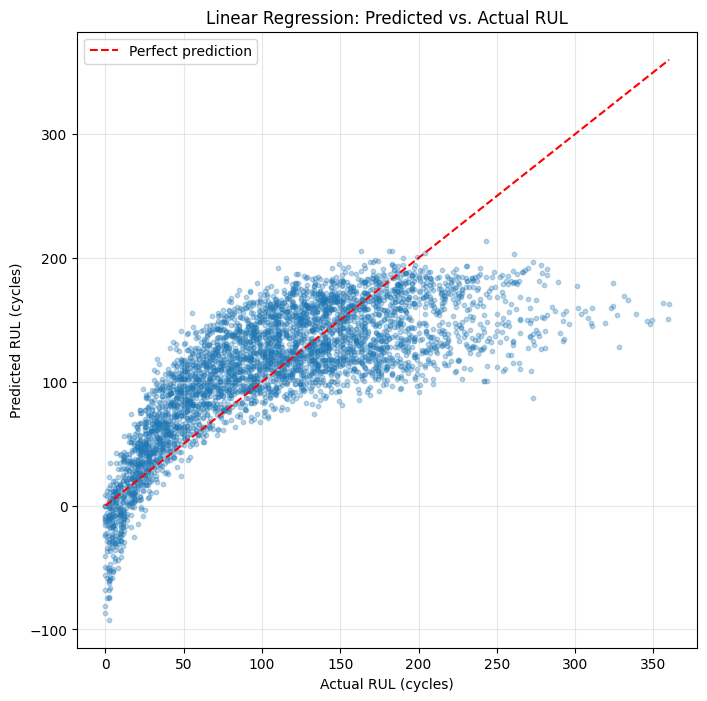

In [ ]:
# Step 7: Visualize predictions vs. actual RUL

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.3, s=10)

# A perfect model would put every point exactly on this diagonal line
max_val = max(y_test.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Linear Regression: Predicted vs. Actual RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Step 8: Train a Random Forest and compare it to the baseline

from sklearn.ensemble import RandomForestRegressor

# n_estimators = how many individual decision trees to build and average together
# random_state=42 again, so results are reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"Linear Regression MAE: {mae:.2f} cycles")
print(f"Random Forest MAE:     {rf_mae:.2f} cycles")
print(f"Improvement: {mae - rf_mae:.2f} cycles ({((mae - rf_mae) / mae * 100):.1f}%)")

Linear Regression MAE: 34.07 cycles
Random Forest MAE:     29.59 cycles
Improvement: 4.48 cycles (13.1%)


In [ ]:
# Step 9: Split by ENGINE instead of by row (no leakage between train and test)

import numpy as np

# Get the list of unique engine IDs, then split THAT list 80/20
unique_engines = df_clean['unit_number'].unique()
train_engines, test_engines = train_test_split(unique_engines, test_size=0.2, random_state=42)

# Now build train/test sets by keeping ALL rows for a given engine together
train_df = df_clean[df_clean['unit_number'].isin(train_engines)]
test_df = df_clean[df_clean['unit_number'].isin(test_engines)]

X_train = train_df[feature_cols]
y_train = train_df['RUL']
X_test = test_df[feature_cols]
y_test = test_df['RUL']

print(f"Train: {len(train_engines)} engines, {len(X_train)} rows")
print(f"Test:  {len(test_engines)} engines, {len(X_test)} rows")

# Retrain both models on the honest split
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mae = mean_absolute_error(y_test, lr_model.predict(X_test))

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"\nLinear Regression MAE (honest split): {lr_mae:.2f} cycles")
print(f"Random Forest MAE (honest split):     {rf_mae:.2f} cycles")

Train: 80 engines, 16561 rows
Test:  20 engines, 4070 rows

Linear Regression MAE (honest split): 30.13 cycles
Random Forest MAE (honest split):     26.02 cycles


sensor_11       0.431788
sensor_9        0.125721
sensor_4        0.077643
sensor_12       0.046630
sensor_14       0.040821
sensor_7        0.037907
sensor_15       0.033421
sensor_21       0.032455
sensor_3        0.029785
sensor_2        0.028309
sensor_20       0.024910
op_setting_1    0.024275
sensor_8        0.021229
sensor_13       0.020806
op_setting_2    0.014705
sensor_17       0.009595
op_setting_3    0.000000
dtype: float64


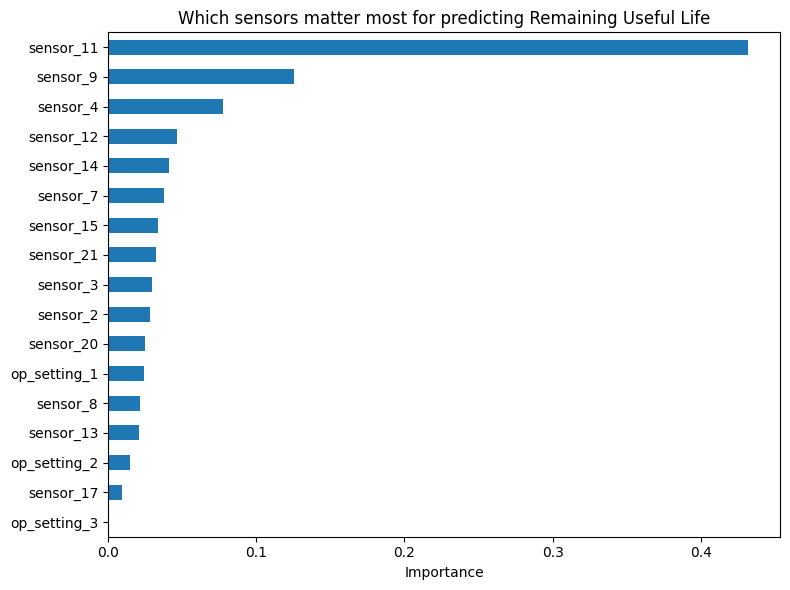

In [ ]:
# Step 10: Feature importance — what did the Random Forest actually rely on?

importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print(importances)

# Visualize it
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Which sensors matter most for predicting Remaining Useful Life')
plt.gca().invert_yaxis()  # highest importance at top
plt.tight_layout()
plt.show()

In [ ]:
# Step 11: Clip RUL at 125 and retrain — focus the model on the degradation zone

CLIP_VALUE = 125

y_train_clipped = y_train.clip(upper=CLIP_VALUE)
y_test_clipped = y_test.clip(upper=CLIP_VALUE)

rf_model_clipped = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_clipped.fit(X_train, y_train_clipped)

rf_clipped_predictions = rf_model_clipped.predict(X_test)
rf_clipped_mae = mean_absolute_error(y_test_clipped, rf_clipped_predictions)

print(f"Random Forest MAE (unclipped):        {rf_mae:.2f} cycles")
print(f"Random Forest MAE (clipped at {CLIP_VALUE}):   {rf_clipped_mae:.2f} cycles")

Random Forest MAE (unclipped):        26.02 cycles
Random Forest MAE (clipped at 125):   12.58 cycles


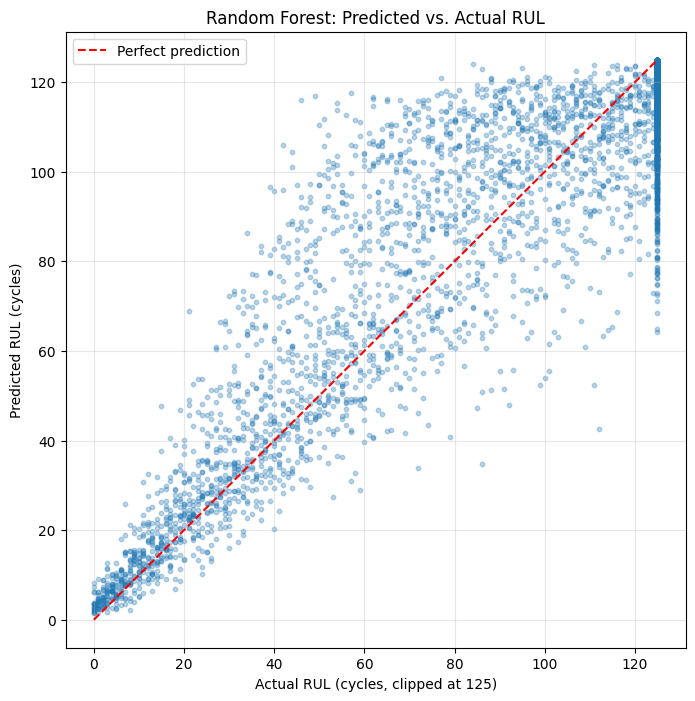

In [ ]:
# Step 12: Visualize Random Forest predictions vs. actual RUL (clipped model)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_clipped, rf_clipped_predictions, alpha=0.3, s=10)

max_val = max(y_test_clipped.max(), rf_clipped_predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual RUL (cycles, clipped at 125)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Random Forest: Predicted vs. Actual RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()